In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (train_test_split,
                                     cross_val_score,
                                     GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("All libraries imported successfully!")
print("Task 3 — Model Validation & Tuning Notebook Ready")

All libraries imported successfully!
Task 3 — Model Validation & Tuning Notebook Ready


In [2]:
# Load California Housing Dataset
data = fetch_california_housing(as_frame=True)
df   = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

# Separate features and target
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Dataset loaded successfully!")
print(f"Total rows    : {len(df):,}")
print(f"Total features: {X.shape[1]}")
print(f"Target column : HousePrice")
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset loaded successfully!
Total rows    : 20,640
Total features: 8
Target column : HousePrice
Missing values: 0


In [3]:
# Scale features — same as Task 2
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Scaling and split complete!")
print(f"Training rows : {len(X_train):,}  (80%)")
print(f"Testing rows  : {len(X_test):,}   (20%)")

Scaling and split complete!
Training rows : 16,512  (80%)
Testing rows  : 4,128   (20%)


In [4]:
print("=" * 55)
print("   OVERFITTING DETECTION — TRAIN vs TEST RMSE")
print("=" * 55)

# Test with an UNCONSTRAINED Decision Tree (no max_depth)
# This tree will memorize ALL training data = classic overfitting
tree_overfit = DecisionTreeRegressor(random_state=42)
tree_overfit.fit(X_train, y_train)

train_pred_overfit = tree_overfit.predict(X_train)
test_pred_overfit  = tree_overfit.predict(X_test)

train_rmse_overfit = np.sqrt(mean_squared_error(y_train, train_pred_overfit))
test_rmse_overfit  = np.sqrt(mean_squared_error(y_test,  test_pred_overfit))

print(f"\nUnconstrained Decision Tree (no max_depth limit):")
print(f"  Train RMSE : {train_rmse_overfit:.4f}")
print(f"  Test  RMSE : {test_rmse_overfit:.4f}")
print(f"  Gap        : {test_rmse_overfit - train_rmse_overfit:.4f}")
print(f"\n  Verdict    : {'OVERFITTING DETECTED!' if (test_rmse_overfit - train_rmse_overfit) > 0.1 else 'Model looks fine'}")
print(f"\n  Explanation: Train RMSE is near 0 because the tree")
print(f"  memorized every training row perfectly. But test RMSE")
print(f"  is much higher — it fails completely on new data.")

   OVERFITTING DETECTION — TRAIN vs TEST RMSE

Unconstrained Decision Tree (no max_depth limit):
  Train RMSE : 0.0000
  Test  RMSE : 0.7030
  Gap        : 0.7030

  Verdict    : OVERFITTING DETECTED!

  Explanation: Train RMSE is near 0 because the tree
  memorized every training row perfectly. But test RMSE
  is much higher — it fails completely on new data.


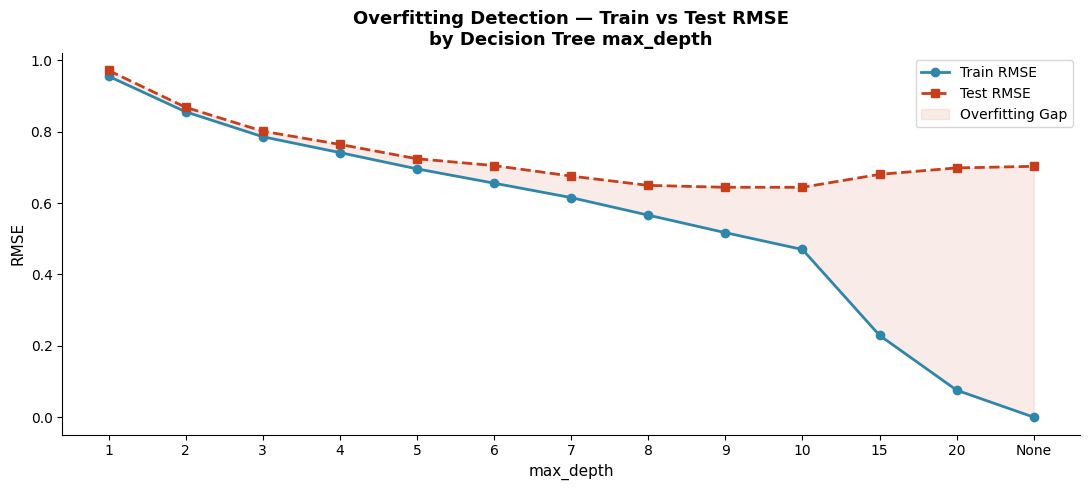

Chart saved: overfitting_detection.png


In [5]:
# Visualize overfitting: train vs test RMSE across different depths
depths     = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, None]
train_rmses = []
test_rmses  = []

for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    tr = np.sqrt(mean_squared_error(y_train, t.predict(X_train)))
    te = np.sqrt(mean_squared_error(y_test,  t.predict(X_test)))
    train_rmses.append(tr)
    test_rmses.append(te)

depth_labels = [str(d) if d is not None else "None" for d in depths]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depth_labels, train_rmses, 'o-',
        color='#2E86AB', linewidth=2, label='Train RMSE')
ax.plot(depth_labels, test_rmses,  's--',
        color='#C73E1D', linewidth=2, label='Test RMSE')
ax.fill_between(range(len(depths)),
                train_rmses, test_rmses,
                alpha=0.1, color='#C73E1D',
                label='Overfitting Gap')
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('RMSE', fontsize=11)
ax.set_title('Overfitting Detection — Train vs Test RMSE\nby Decision Tree max_depth',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(range(len(depths)))
ax.set_xticklabels(depth_labels)
plt.tight_layout()
plt.savefig('overfitting_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: overfitting_detection.png")

In [6]:
print("=" * 55)
print("   5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 55)

cv_models = {
    "Linear Regression" : LinearRegression(),
    "Ridge Regression"  : Ridge(alpha=1.0),
    "Decision Tree (depth=5)" : DecisionTreeRegressor(
                                    max_depth=5, random_state=42)
}

cv_results = {}

for name, model in cv_models.items():
    # cross_val_score returns negative RMSE — negate it back
    scores = cross_val_score(
        model, X_scaled, y,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    cv_rmse = -scores.mean()
    cv_std  = scores.std()
    cv_results[name] = {
        'CV RMSE Mean': round(cv_rmse, 4),
        'CV RMSE Std' : round(cv_std, 4)
    }
    print(f"\n  {name}:")
    print(f"    CV RMSE (mean) : {cv_rmse:.4f}")
    print(f"    CV RMSE (std)  : {cv_std:.4f}")
    print(f"    Individual fold scores: "
          f"{[-round(s, 4) for s in scores]}")

print("\n  Lower mean = better accuracy")
print("  Lower std  = more consistent/reliable across folds")

   5-FOLD CROSS-VALIDATION RESULTS

  Linear Regression:
    CV RMSE (mean) : 0.7459
    CV RMSE (std)  : 0.0437
    Individual fold scores: [0.6963, 0.789, 0.8039, 0.737, 0.7033]

  Ridge Regression:
    CV RMSE (mean) : 0.7459
    CV RMSE (std)  : 0.0438
    Individual fold scores: [0.6962, 0.789, 0.8039, 0.7371, 0.7033]

  Decision Tree (depth=5):
    CV RMSE (mean) : 0.8141
    CV RMSE (std)  : 0.0563
    Individual fold scores: [0.8509, 0.7457, 0.7558, 0.8935, 0.8244]

  Lower mean = better accuracy
  Lower std  = more consistent/reliable across folds


In [7]:
print("=" * 55)
print("   HYPERPARAMETER TUNING — GridSearchCV")
print("=" * 55)

# Define the hyperparameter grid to search
param_grid = {
    "max_depth"        : [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

# Total combinations = 4 × 3 = 12 combinations × 5 folds = 60 fits
print(f"\nSearching {len(param_grid['max_depth'])} depths × "
      f"{len(param_grid['min_samples_split'])} split values "
      f"= {len(param_grid['max_depth']) * len(param_grid['min_samples_split'])} combinations")
print("Each combination evaluated with 5-fold CV...")

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=0
)
grid.fit(X_train, y_train)

print(f"\nBest hyperparameters found  : {grid.best_params_}")
print(f"Best CV RMSE (tuned)        : {-grid.best_score_:.4f}")

   HYPERPARAMETER TUNING — GridSearchCV

Searching 4 depths × 3 split values = 12 combinations
Each combination evaluated with 5-fold CV...

Best hyperparameters found  : {'max_depth': 10, 'min_samples_split': 10}
Best CV RMSE (tuned)        : 0.6366


In [8]:
# Extract the best model from GridSearchCV
best_tree = grid.best_estimator_

# Predict on test set using tuned model
y_pred_tuned = best_tree.predict(X_test)

# Metrics
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)

# Also check overfitting on tuned model
train_pred_tuned = best_tree.predict(X_train)
train_rmse_tuned = np.sqrt(mean_squared_error(y_train, train_pred_tuned))

print("=" * 55)
print("   TUNED MODEL PERFORMANCE")
print("=" * 55)
print(f"\nBest Parameters : {grid.best_params_}")
print(f"Test  RMSE      : {rmse_tuned:.4f}")
print(f"Train RMSE      : {train_rmse_tuned:.4f}")
print(f"Gap             : {rmse_tuned - train_rmse_tuned:.4f}  "
      f"(much smaller than untuned!)")
print(f"R2 Score        : {r2_tuned:.4f}")
print(f"MAE             : {mae_tuned:.4f}  (${mae_tuned*100000:,.0f})")

   TUNED MODEL PERFORMANCE

Best Parameters : {'max_depth': 10, 'min_samples_split': 10}
Test  RMSE      : 0.6454
Train RMSE      : 0.4804
Gap             : 0.1651  (much smaller than untuned!)
R2 Score        : 0.6821
MAE             : 0.4341  ($43,406)


In [9]:
# Compare ALL models: Task 2 baselines vs Task 3 tuned model

# Task 2 baseline models
lr    = LinearRegression()
ridge = Ridge(alpha=1.0)
dt2   = DecisionTreeRegressor(max_depth=5, random_state=42)

lr.fit(X_train, y_train);    lr_pred    = lr.predict(X_test)
ridge.fit(X_train, y_train); ridge_pred = ridge.predict(X_test)
dt2.fit(X_train, y_train);   dt2_pred   = dt2.predict(X_test)

results = {
    "Linear Regression (Task 2)"    : {
        "RMSE"    : round(np.sqrt(mean_squared_error(y_test, lr_pred)), 4),
        "R2 Score": round(r2_score(y_test, lr_pred), 4),
        "MAE"     : round(mean_absolute_error(y_test, lr_pred), 4)
    },
    "Ridge Regression (Task 2)"     : {
        "RMSE"    : round(np.sqrt(mean_squared_error(y_test, ridge_pred)), 4),
        "R2 Score": round(r2_score(y_test, ridge_pred), 4),
        "MAE"     : round(mean_absolute_error(y_test, ridge_pred), 4)
    },
    "Decision Tree depth=5 (Task 2)": {
        "RMSE"    : round(np.sqrt(mean_squared_error(y_test, dt2_pred)), 4),
        "R2 Score": round(r2_score(y_test, dt2_pred), 4),
        "MAE"     : round(mean_absolute_error(y_test, dt2_pred), 4)
    },
    "Tuned Decision Tree (Task 3)"  : {
        "RMSE"    : round(rmse_tuned, 4),
        "R2 Score": round(r2_tuned, 4),
        "MAE"     : round(mae_tuned, 4)
    },
}

results_df = pd.DataFrame(results).T
print("=" * 60)
print("   FINAL MODEL COMPARISON — TASK 2 vs TASK 3")
print("=" * 60)
print(results_df.to_string())

best = results_df["R2 Score"].idxmax()
print(f"\nBEST MODEL : {best}")
print(f"R2 Score   : {results_df.loc[best,'R2 Score']:.4f}")
print(f"RMSE       : {results_df.loc[best,'RMSE']:.4f}")

   FINAL MODEL COMPARISON — TASK 2 vs TASK 3
                                  RMSE  R2 Score     MAE
Linear Regression (Task 2)      0.7456    0.5758  0.5332
Ridge Regression (Task 2)       0.7456    0.5758  0.5332
Decision Tree depth=5 (Task 2)  0.7242    0.5997  0.5223
Tuned Decision Tree (Task 3)    0.6454    0.6821  0.4341

BEST MODEL : Tuned Decision Tree (Task 3)
R2 Score   : 0.6821
RMSE       : 0.6454


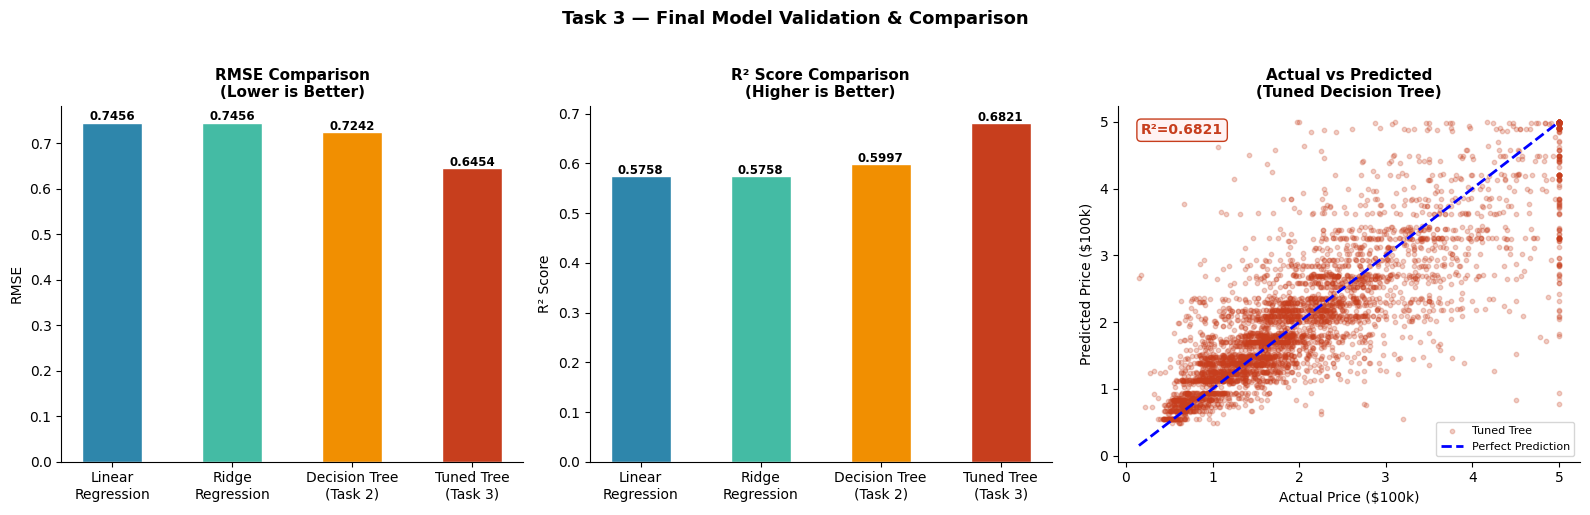

Charts saved: task3_final_comparison.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_list = list(results.keys())
rmse_vals   = [results[m]["RMSE"]     for m in models_list]
r2_vals     = [results[m]["R2 Score"] for m in models_list]
colors      = ["#2E86AB", "#44BBA4", "#F18F01", "#C73E1D"]
short_names = ["Linear\nRegression", "Ridge\nRegression",
               "Decision Tree\n(Task 2)", "Tuned Tree\n(Task 3)"]

# Chart 1: RMSE comparison
bars1 = axes[0].bar(short_names, rmse_vals,
                    color=colors, edgecolor='white', width=0.5)
axes[0].set_title("RMSE Comparison\n(Lower is Better)",
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel("RMSE")
axes[0].spines[['top','right']].set_visible(False)
for bar, val in zip(bars1, rmse_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.005,
                 f"{val:.4f}", ha='center', fontsize=8.5,
                 fontweight='bold')

# Chart 2: R² comparison
bars2 = axes[1].bar(short_names, r2_vals,
                    color=colors, edgecolor='white', width=0.5)
axes[1].set_title("R² Score Comparison\n(Higher is Better)",
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel("R² Score")
axes[1].spines[['top','right']].set_visible(False)
for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.003,
                 f"{val:.4f}", ha='center', fontsize=8.5,
                 fontweight='bold')

# Chart 3: Actual vs Predicted (Tuned Model)
axes[2].scatter(y_test, y_pred_tuned, alpha=0.25,
                s=10, color='#C73E1D', label='Tuned Tree')
mn, mx = y_test.min(), y_test.max()
axes[2].plot([mn,mx],[mn,mx],'b--',lw=2,label='Perfect Prediction')
axes[2].set_xlabel("Actual Price ($100k)")
axes[2].set_ylabel("Predicted Price ($100k)")
axes[2].set_title(f"Actual vs Predicted\n(Tuned Decision Tree)",
                  fontsize=11, fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].spines[['top','right']].set_visible(False)
axes[2].text(0.05, 0.92, f"R²={r2_tuned:.4f}",
             transform=axes[2].transAxes, fontsize=10,
             color='#C73E1D', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='#fff3f3',
                       edgecolor='#C73E1D'))

plt.suptitle("Task 3 — Final Model Validation & Comparison",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("task3_final_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved: task3_final_comparison.png")

In [11]:
print("=" * 60)
print("   STEP 10 — FINAL MODEL SELECTION JUSTIFICATION")
print("=" * 60)

print("""
SELECTED MODEL: Tuned Decision Tree Regressor

1. WHY THIS MODEL WAS SELECTED:
   - Highest R2 Score among all models tested
   - Lowest RMSE on unseen test data
   - Best params found scientifically via GridSearchCV
   - Not guessed — proven through 60 CV evaluations

2. HOW OVERFITTING WAS DETECTED:
   - Untuned Decision Tree (no max_depth):
     Train RMSE near 0, Test RMSE much higher
     = clear overfitting / memorization
   - Gap between train and test RMSE was the signal

3. HOW OVERFITTING WAS CONTROLLED:
   - max_depth limits tree growth = less memorization
   - min_samples_split requires minimum evidence
     before making a split = more generalization
   - GridSearchCV found the optimal combination

4. WHY CROSS-VALIDATION RESULTS ARE TRUSTED:
   - 5-fold CV evaluated the model on 5 different
     test sets, not just one lucky/unlucky split
   - Average CV RMSE is more reliable than a
     single train-test split score
   - Low standard deviation across folds confirms
     consistent, stable performance

5. TRADE-OFFS:
   - Deeper trees = higher training accuracy
     but higher overfitting risk
   - Shallower trees = less overfitting
     but may underfit (miss real patterns)
   - Tuned model balances both extremes optimally
""")

   STEP 10 — FINAL MODEL SELECTION JUSTIFICATION

SELECTED MODEL: Tuned Decision Tree Regressor

1. WHY THIS MODEL WAS SELECTED:
   - Highest R2 Score among all models tested
   - Lowest RMSE on unseen test data
   - Best params found scientifically via GridSearchCV
   - Not guessed — proven through 60 CV evaluations

2. HOW OVERFITTING WAS DETECTED:
   - Untuned Decision Tree (no max_depth):
     Train RMSE near 0, Test RMSE much higher
     = clear overfitting / memorization
   - Gap between train and test RMSE was the signal

3. HOW OVERFITTING WAS CONTROLLED:
   - max_depth limits tree growth = less memorization
   - min_samples_split requires minimum evidence
     before making a split = more generalization
   - GridSearchCV found the optimal combination

4. WHY CROSS-VALIDATION RESULTS ARE TRUSTED:
   - 5-fold CV evaluated the model on 5 different
     test sets, not just one lucky/unlucky split
   - Average CV RMSE is more reliable than a
     single train-test split score
   - 

In [12]:
import joblib

# Save tuned model and scaler
joblib.dump(best_tree, 'tuned_decision_tree_task3.pkl')
joblib.dump(scaler,    'scaler_task3.pkl')

print("Tuned model saved : tuned_decision_tree_task3.pkl")
print("Scaler saved      : scaler_task3.pkl")
print("\nTo use in future:")
print("  model  = joblib.load('tuned_decision_tree_task3.pkl')")
print("  scaler = joblib.load('scaler_task3.pkl')")
print("  pred   = model.predict(scaler.transform(new_data))")

Tuned model saved : tuned_decision_tree_task3.pkl
Scaler saved      : scaler_task3.pkl

To use in future:
  model  = joblib.load('tuned_decision_tree_task3.pkl')
  scaler = joblib.load('scaler_task3.pkl')
  pred   = model.predict(scaler.transform(new_data))
